# Stable Diffusion API Image Generation and Editing

**Student:** Adjovi Gloria Lembila  
**Course:** DSC670 Advanced Uses of Generative AI  
**Instructor:** Professor Frank Neugebauer  
**Date:** June 23, 2026

## Purpose
The purpose of this exercise is to explore how generative artificial intelligence can be used to create and modify images through the Stable Diffusion API. I use a Jupyter Notebook to connect to the API, generate an image from a text prompt, and then edit that image by introducing additional visual details. The notebook includes code, outputs, and documentation so each step of the process is clear and reproducible.


## Step 1: Install and Import Required Libraries

The code below installs and imports the Python libraries needed for the API workflow. The `requests` library sends information to the Stability AI API, `PIL` opens and displays image files, `matplotlib` shows the generated images directly in the notebook, and `pathlib` helps organize output files. I am using an API instead of running Stable Diffusion locally because API-based image generation does not require a high-end graphics card.


In [12]:
# Run this cell one time if the libraries are not already installed.
# The -q option keeps the installation output short and clean.
!pip install requests pillow matplotlib python-dotenv -q

# Import libraries used for file paths, API requests, and image display.
import os
import requests
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Create a folder to store the generated and edited images.
# This keeps the notebook outputs organized and easy to find.
OUTPUT_DIR = Path('stable_diffusion_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Setup complete. Output folder:', OUTPUT_DIR.resolve())


Setup complete. Output folder: C:\Users\adjov\3.2  670 class\stable_diffusion_outputs


## Step 2: Configure the API Key

The Stability AI API requires an API key for authentication. This notebook looks for the key in an environment variable named `STABILITY_API_KEY`. Storing the key this way is safer than writing the key directly into the notebook because it helps protect private account information.


In [15]:
# Option A: Set your API key as an environment variable before opening Jupyter.
# Option B: Paste it below when the notebook asks for it.

# Check whether the API key already exists in the environment.
# If it does not exist, the notebook asks the user to paste it securely.
if not os.getenv('STABILITY_API_KEY'):
    os.environ['STABILITY_API_KEY'] = input('Paste your Stability AI API key here: ').strip()

# Store the API key in a variable so it can be used in the API request headers.
API_KEY = os.getenv('STABILITY_API_KEY')
assert API_KEY, 'API key is missing.'
print('API key loaded successfully.')


API key loaded successfully.


## Step 3: Generate an Image From a Text Prompt

For the first API call, I use a detailed prompt describing an AI-powered renewable energy control room. I selected this topic because it connects to generative AI, data dashboards, engineering, and clean energy. The prompt includes subject matter, setting, lighting, and style details so the model has clearer instructions.


In [14]:
# Create a detailed prompt describing the image to generate.
# Specific details help Stable Diffusion create a more accurate and professional image.
generation_prompt = (
    'A futuristic renewable energy control center using artificial intelligence to manage '
    'solar panels, wind turbines, and battery storage, engineers monitoring dashboards, '
    'photorealistic, professional, cinematic lighting, highly detailed'
)

# Send a POST request to the Stability AI image generation endpoint.
# The request includes the prompt, image format, and aspect ratio.
response = requests.post(
    'https://api.stability.ai/v2beta/stable-image/generate/core',
    headers={
        'Authorization': f'Bearer {API_KEY}',
        'Accept': 'image/*'
    },
    files={'none': ''},
    data={
        'prompt': generation_prompt,
        'output_format': 'png',
        'aspect_ratio': '16:9'
    },
    timeout=120
)

# Check whether the API request was successful.
# If the request fails, this error message helps identify the issue.
if response.status_code != 200:
    raise Exception(f'Generation failed: {response.status_code} - {response.text}')

# Save the generated image locally so it can be displayed and used later for editing.
generated_path = OUTPUT_DIR / 'generated_energy_control_center.png'
generated_path.write_bytes(response.content)
print('Generated image saved to:', generated_path)


Generated image saved to: stable_diffusion_outputs\generated_energy_control_center.png


### Documentation: Image Generation Results

The generated image should reflect the prompt describing a futuristic renewable energy control center. The model uses the descriptive language in the prompt to create visual elements such as engineers, AI-powered dashboards, renewable energy systems, solar panels, wind turbines, battery storage, and professional lighting. This step demonstrates how prompt engineering directly influences the quality and content of generative AI outputs.


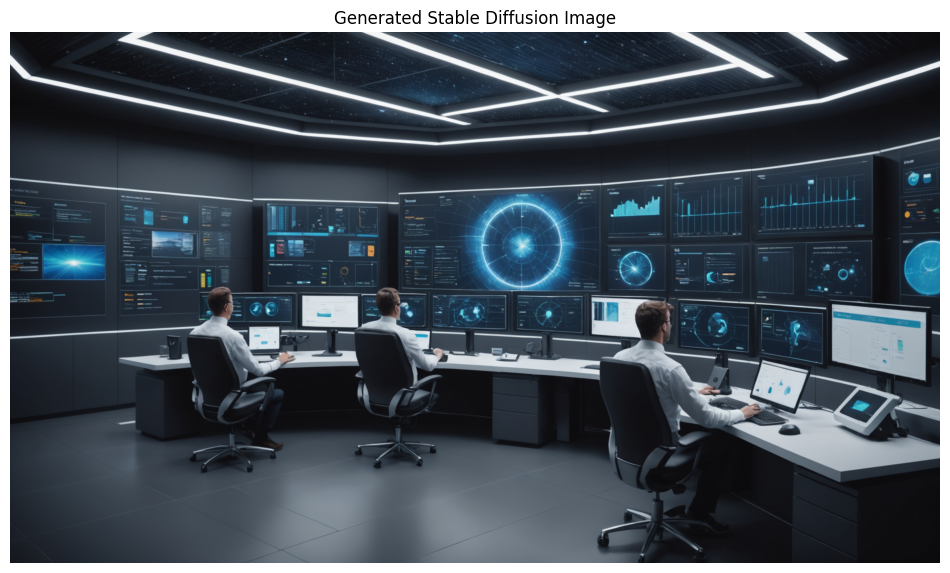

In [10]:
# Load the generated image from the output folder.
# Displaying the image in the notebook allows the result to be reviewed immediately.
img = Image.open(generated_path)
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis('off')
plt.title('Generated Stable Diffusion Image')
plt.show()


## Step 4: Edit the Generated Image

This section edits the image created in the previous step instead of generating a completely new image. The editing prompt asks the model to add brighter holographic energy-flow lines, clearer AI dashboards, and a cleaner futuristic appearance while keeping the original renewable energy control room. This shows how prompt-based editing can refine an existing image while preserving its main subject.


In [11]:
# Create a prompt describing the changes to make to the existing image.
# The prompt asks for improvements while preserving the original subject.
edit_prompt = (
    'Add brighter holographic energy-flow lines, more visible AI dashboards, and a cleaner futuristic look. '
    'Keep the renewable energy control room, engineers, solar panels, and wind turbines.'
)

# Open the previously generated image and send it to the Stability AI editing endpoint.
# The search_prompt tells the model which part of the image should be modified.
with open(generated_path, 'rb') as image_file:
    edit_response = requests.post(
        'https://api.stability.ai/v2beta/stable-image/edit/search-and-replace',
        headers={
            'Authorization': f'Bearer {API_KEY}',
            'Accept': 'image/*'
        },
        files={'image': image_file},
        data={
            'prompt': edit_prompt,
            'search_prompt': 'energy dashboards and control room lighting',
            'output_format': 'png'
        },
        timeout=120
    )

# Check whether the editing request was successful before saving the image.
if edit_response.status_code != 200:
    raise Exception(f'Edit failed: {edit_response.status_code} - {edit_response.text}')

# Save the edited image locally for display and comparison with the original image.
edited_path = OUTPUT_DIR / 'edited_energy_control_center.png'
edited_path.write_bytes(edit_response.content)
print('Edited image saved to:', edited_path)


Edited image saved to: stable_diffusion_outputs\edited_energy_control_center.png


### Documentation: Image Editing Results

The edited image should maintain the original renewable energy control center while enhancing the futuristic elements requested in the editing prompt. The added holographic displays, improved lighting, and clearer AI dashboard features demonstrate how image editing can refine an existing AI-generated image without changing the main idea of the scene.


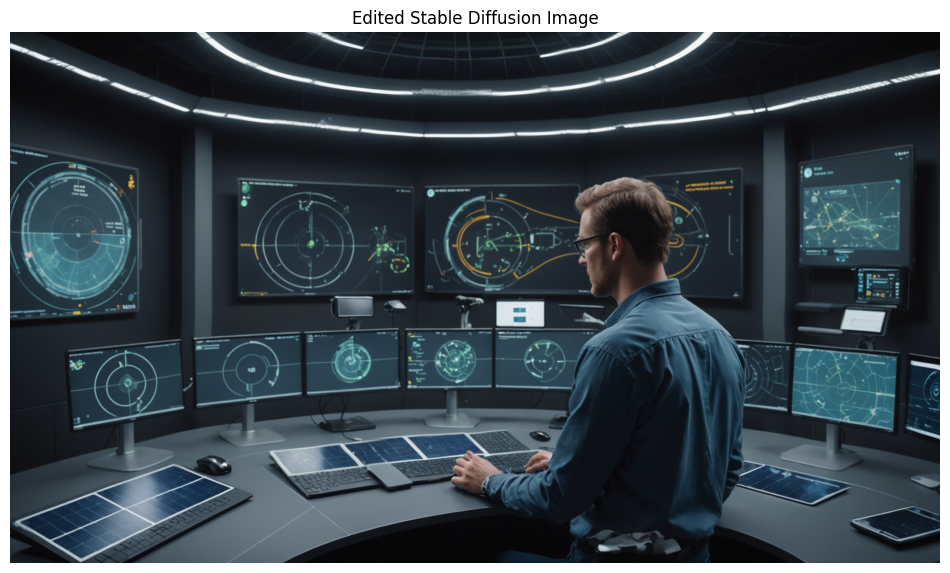

In [6]:
# Load the edited image from the output folder.
# Display the edited version so it can be compared with the original generated image.
edited_img = Image.open(edited_path)
plt.figure(figsize=(12, 7))
plt.imshow(edited_img)
plt.axis('off')
plt.title('Edited Stable Diffusion Image')
plt.show()


## Results and Reflection

Through this exercise, I learned that a generated image should reflect the descriptive details included in the prompt. The original prompt was designed to produce a renewable energy control center with solar, wind, battery, and AI monitoring elements. The detailed wording helped the model understand the technical setting and produce a professional-looking image. The edited image was intended to keep the original subject while adding stronger holographic effects and clearer dashboard emphasis.

The differences between the original and edited images occurred because generative AI models do not simply retrieve existing pictures. Instead, they create new images by predicting visual patterns associated with words and concepts contained in the prompt. When additional details were introduced during editing, the model adjusted its interpretation of the scene and generated new visual elements that reflected those instructions. This demonstrates the importance of prompt engineering, because even small changes in wording can significantly influence the final output.

Using the Stable Diffusion API was moderately challenging. The concept was easy to understand because the API receives a prompt and returns an image, but the setup required attention to details such as the API key, endpoint URL, request headers, image format, and error handling. The most important lesson from this exercise is that code alone is not enough. Markdown explanations and code comments help document why each step was taken and how the result connects to generative AI concepts. Overall, the API was powerful because it allowed image generation and editing from inside Jupyter Notebook, but it required more technical precision than using a web-based image generator.


## References

Stability AI. (2026). *Stable Image API documentation*. https://platform.stability.ai/docs/getting-started/stable-image

Python Software Foundation. (2026). *Python documentation*. https://docs.python.org/3/

Requests Developers. (2026). *Requests: HTTP for Python*. https://requests.readthedocs.io/
